# Dry Bean Type Classification — End-to-End ML Pipeline

**Objective:** Build a multi-class classifier that automates the labeling of 7 dry-bean varieties using 16 shape/size features extracted by computer vision. The final model is saved to disk so it can be served by a Streamlit app (`streamlit_app.py`) — no Docker required.

**Pipeline:**
1. Load & inspect the data
2. Exploratory Data Analysis (EDA)
3. Missing values & outlier treatment
4. Feature engineering & preprocessing (scaling, encoding, stratified split)
5. Train multiple classifiers + cross-validation
6. Handle class imbalance (SMOTE)
7. Evaluation & overfitting check
8. Hyperparameter tuning (GridSearchCV)
9. Model comparison table
10. Save best model + scaler + encoder for the Streamlit app

## 1. Import & Load the Data

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)


sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42

In [2]:
# Load the dataset (update the path if needed)
DATA_PATH = 'Dry_Bean_dataset.xlsx'
df = pd.read_excel(DATA_PATH)

print('Shape:', df.shape)
df.head()

Shape: (13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Area,13611.0,53048.284549,29324.095717,20420.000000,36328.000000,44652.000000,61332.000000,254616.000000
Perimeter,13611.0,855.283459,214.289696,524.736000,703.523500,794.941000,977.213000,1985.370000
MajorAxisLength,13611.0,320.141867,85.694186,183.601165,253.303633,296.883367,376.495012,738.860153
MinorAxisLength,13611.0,202.270714,44.970091,122.512653,175.848170,192.431733,217.031741,460.198497
AspectRation,13611.0,1.583242,0.246678,1.024868,1.432307,1.551124,1.707109,2.430306
Eccentricity,13611.0,0.750895,0.092002,0.218951,0.715928,0.764441,0.810466,0.911423
ConvexArea,13611.0,53768.200206,29774.915817,20684.000000,36714.500000,45178.000000,62294.000000,263261.000000
EquivDiameter,13611.0,253.064220,59.177120,161.243764,215.068003,238.438026,279.446467,569.374358
Extent,13611.0,0.749733,0.049086,0.555315,0.718634,0.759859,0.786851,0.866195
Solidity,13611.0,0.987143,0.004660,0.919246,0.985670,0.988283,0.990013,0.994677


## 2. Exploratory Data Analysis (EDA)

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


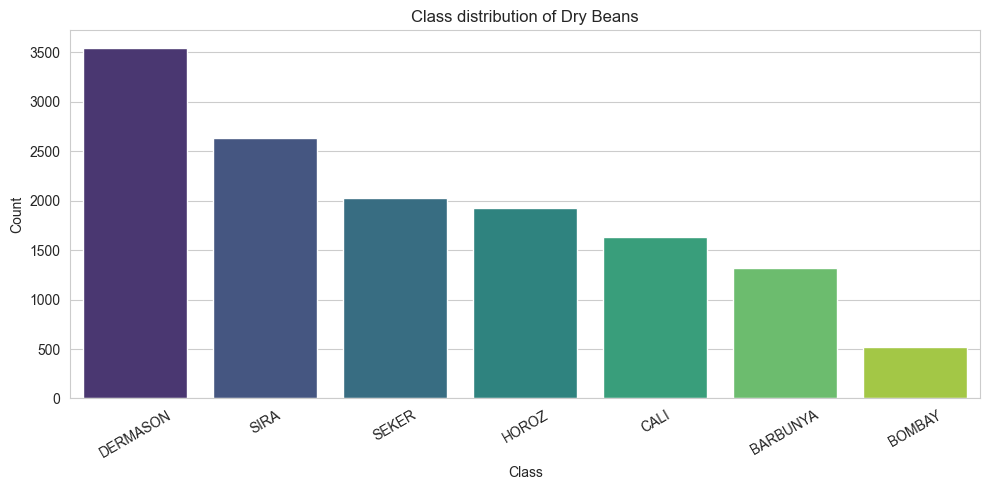

Imbalance ratio (max/min): 6.79


In [5]:
# 2.1 Class distribution — check for imbalance
class_counts = df['Class'].value_counts()
print(class_counts)

plt.figure(figsize=(10, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Class distribution of Dry Beans')
plt.ylabel('Count'); plt.xlabel('Class')
plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

imbalance_ratio = class_counts.max() / class_counts.min()
print(f'Imbalance ratio (max/min): {imbalance_ratio:.2f}')

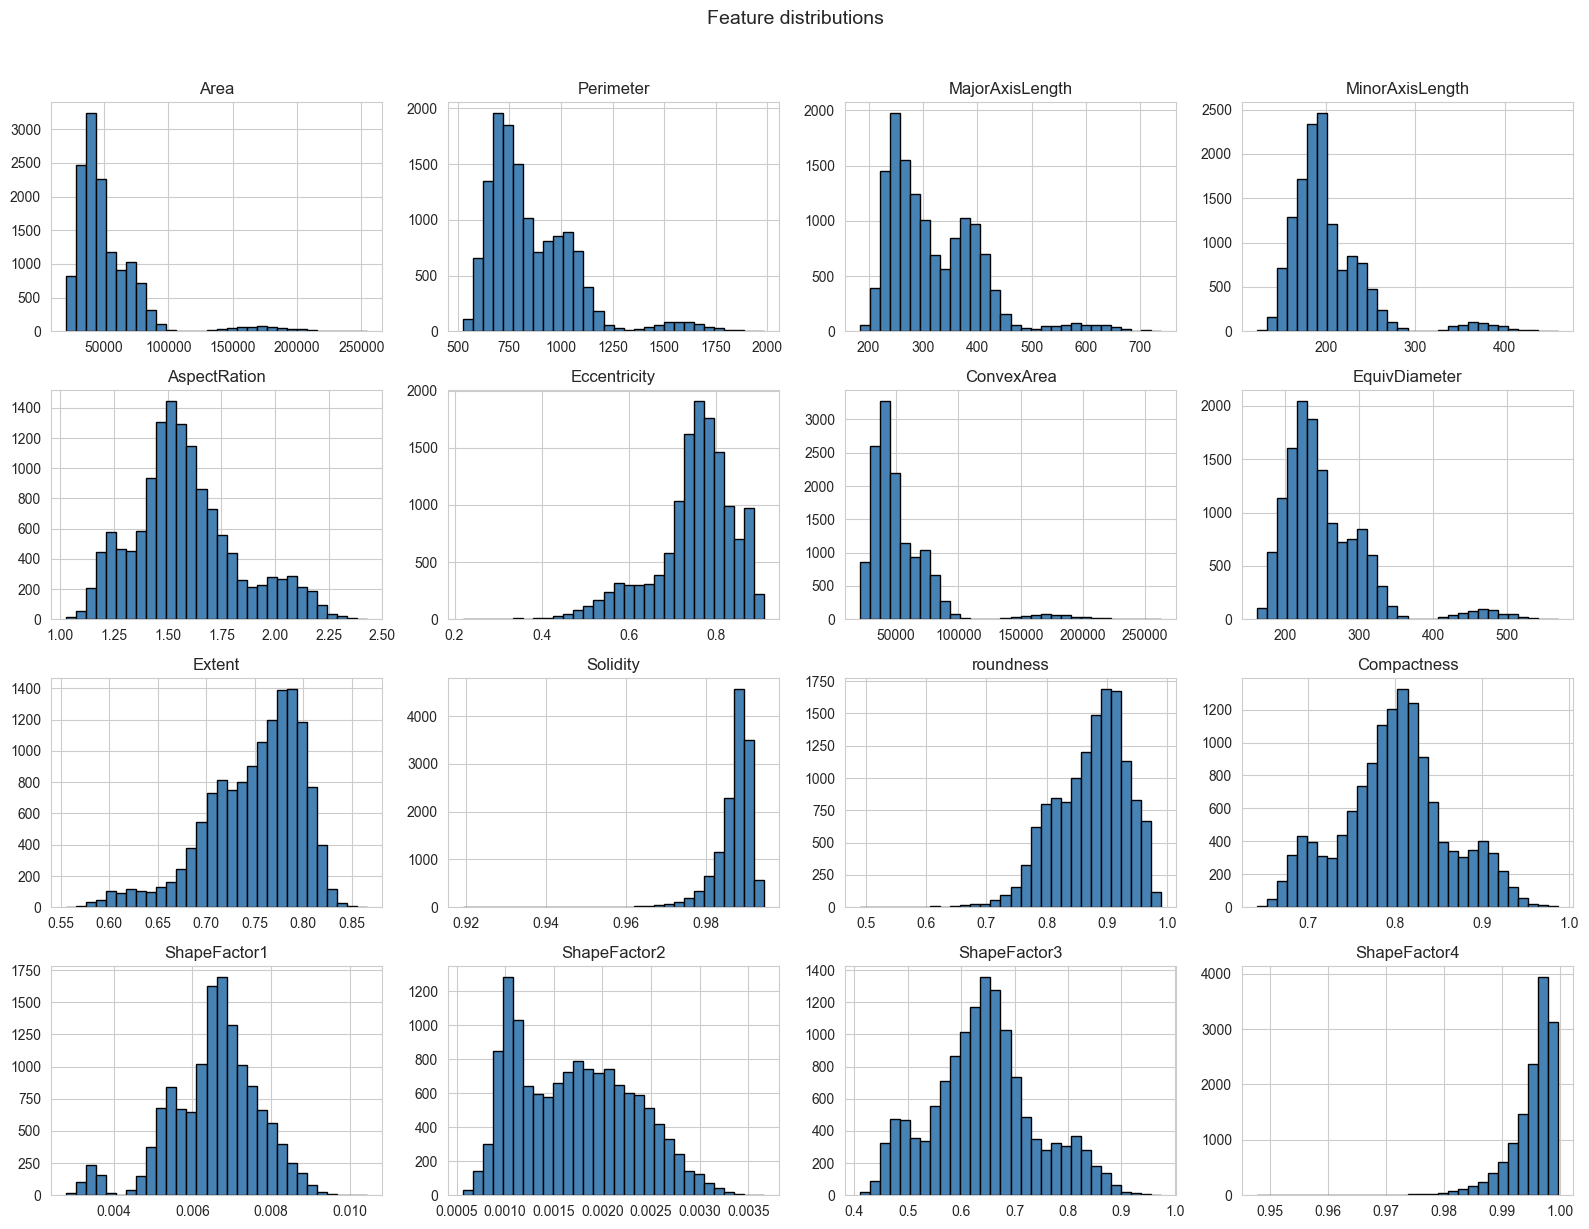

In [6]:
# 2.2 Feature distributions
feature_cols = [c for c in df.columns if c != 'Class']
df[feature_cols].hist(bins=30, figsize=(16, 12), color='steelblue', edgecolor='black')
plt.suptitle('Feature distributions', y=1.02, fontsize=14)
plt.tight_layout(); plt.show()

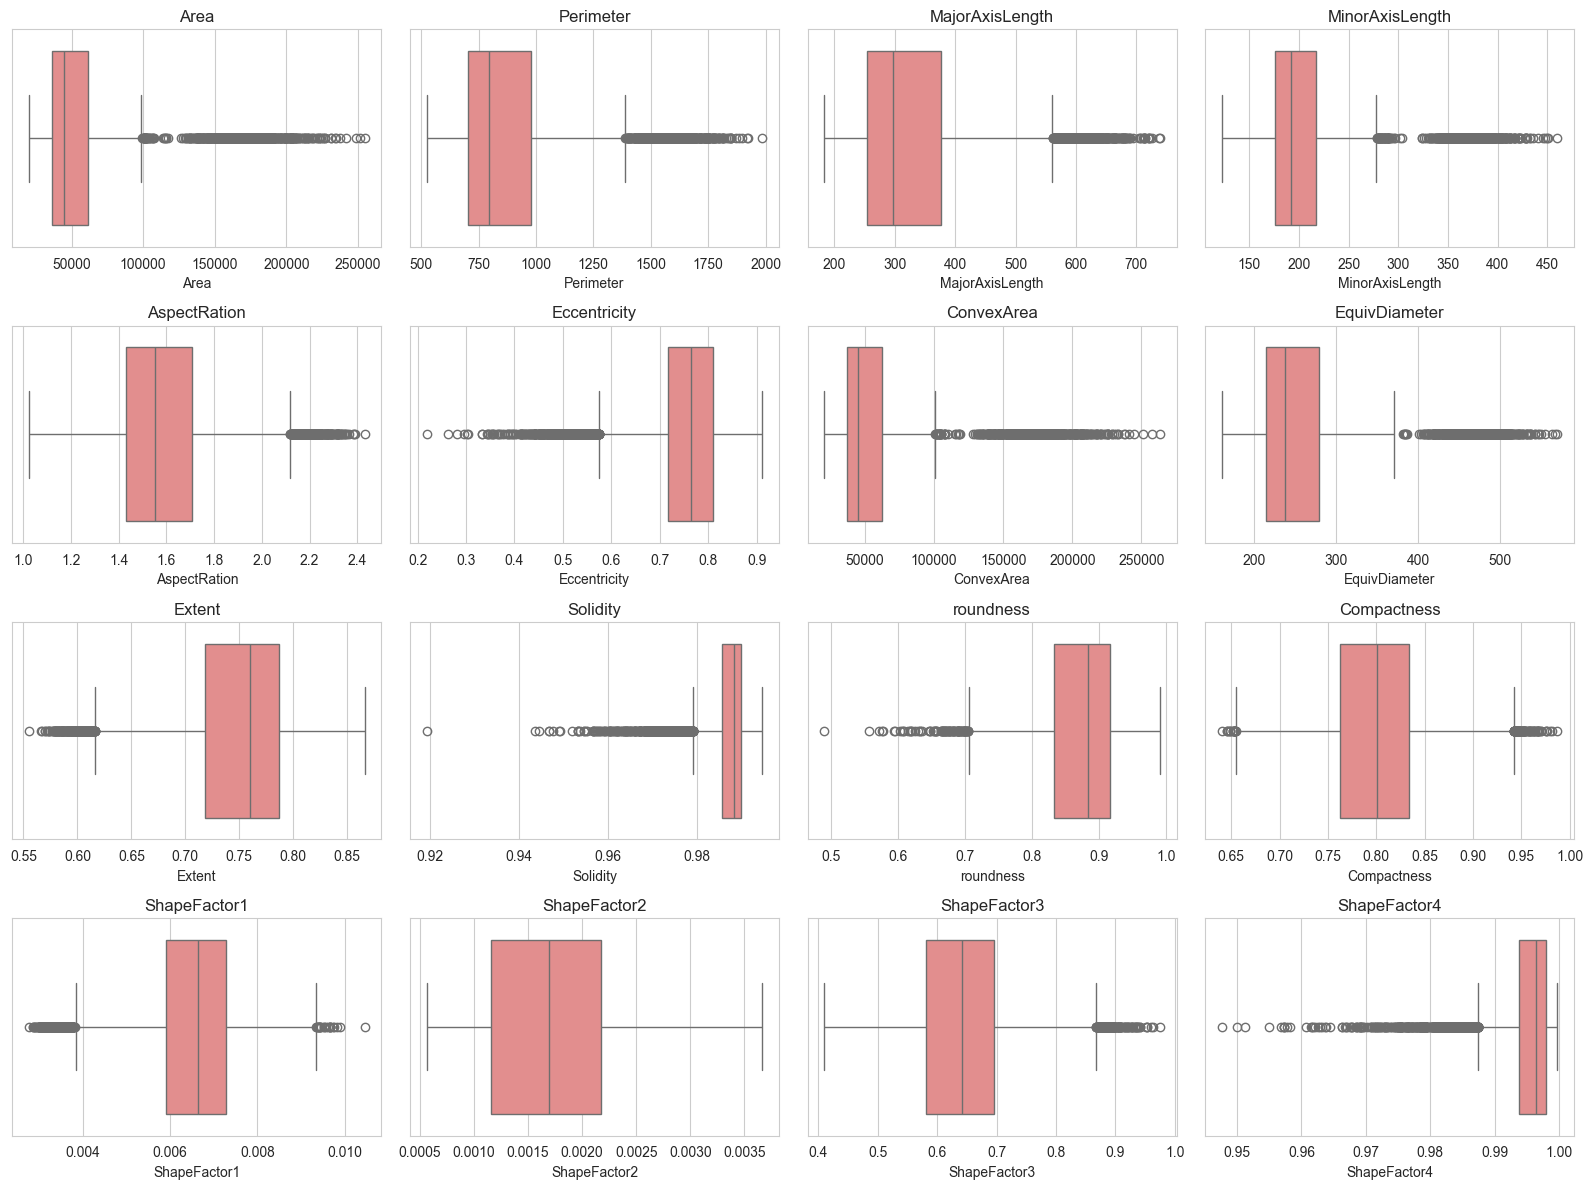

In [7]:
# 2.3 Boxplots to spot outliers
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for ax, col in zip(axes.flatten(), feature_cols):
    sns.boxplot(x=df[col], ax=ax, color='lightcoral')
    ax.set_title(col)
plt.tight_layout(); plt.show()

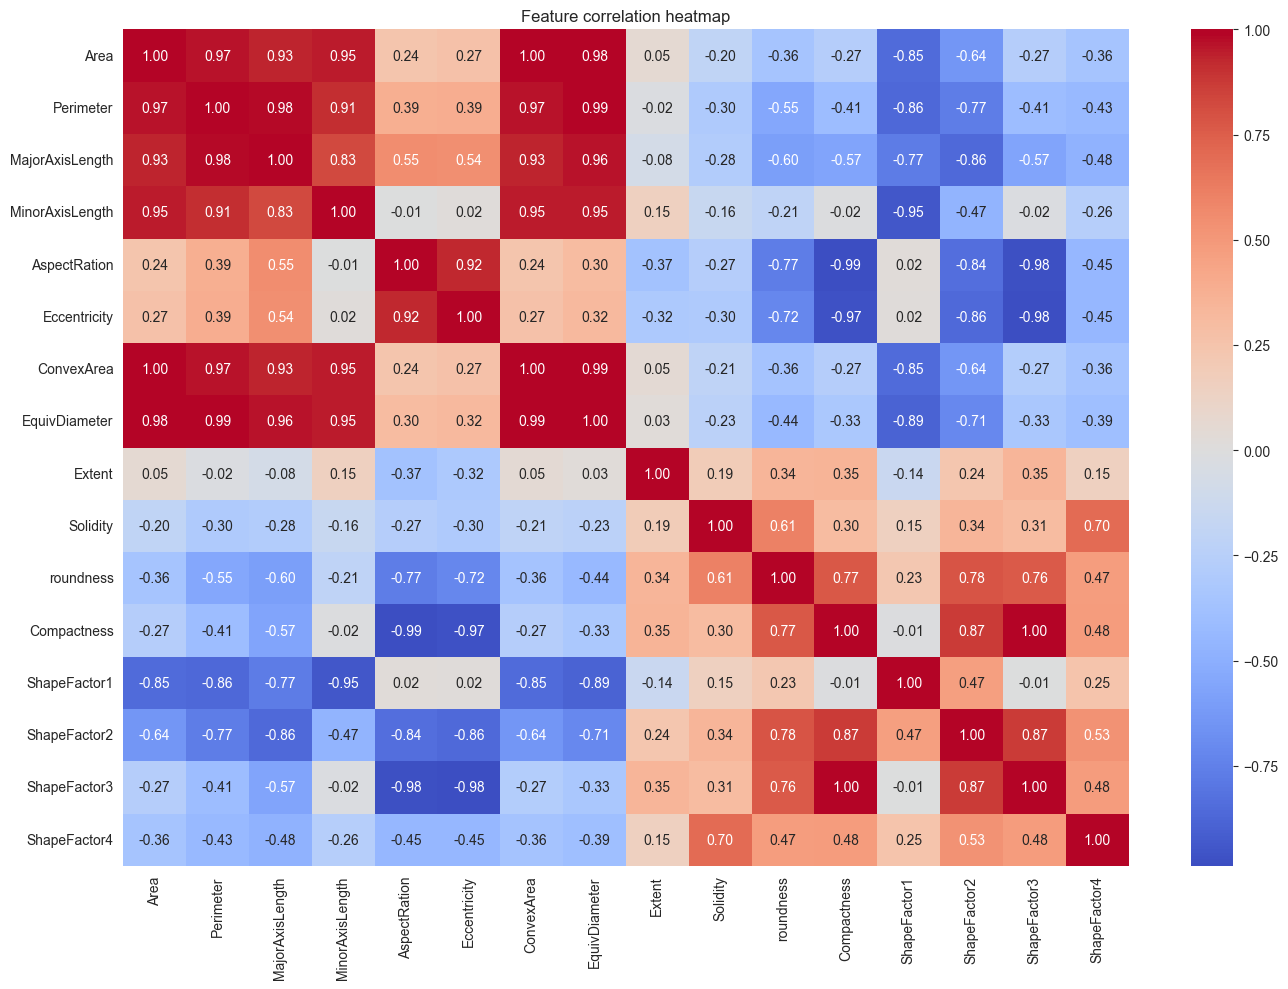

In [8]:
# 2.4 Correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(df[feature_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature correlation heatmap')
plt.tight_layout(); plt.show()

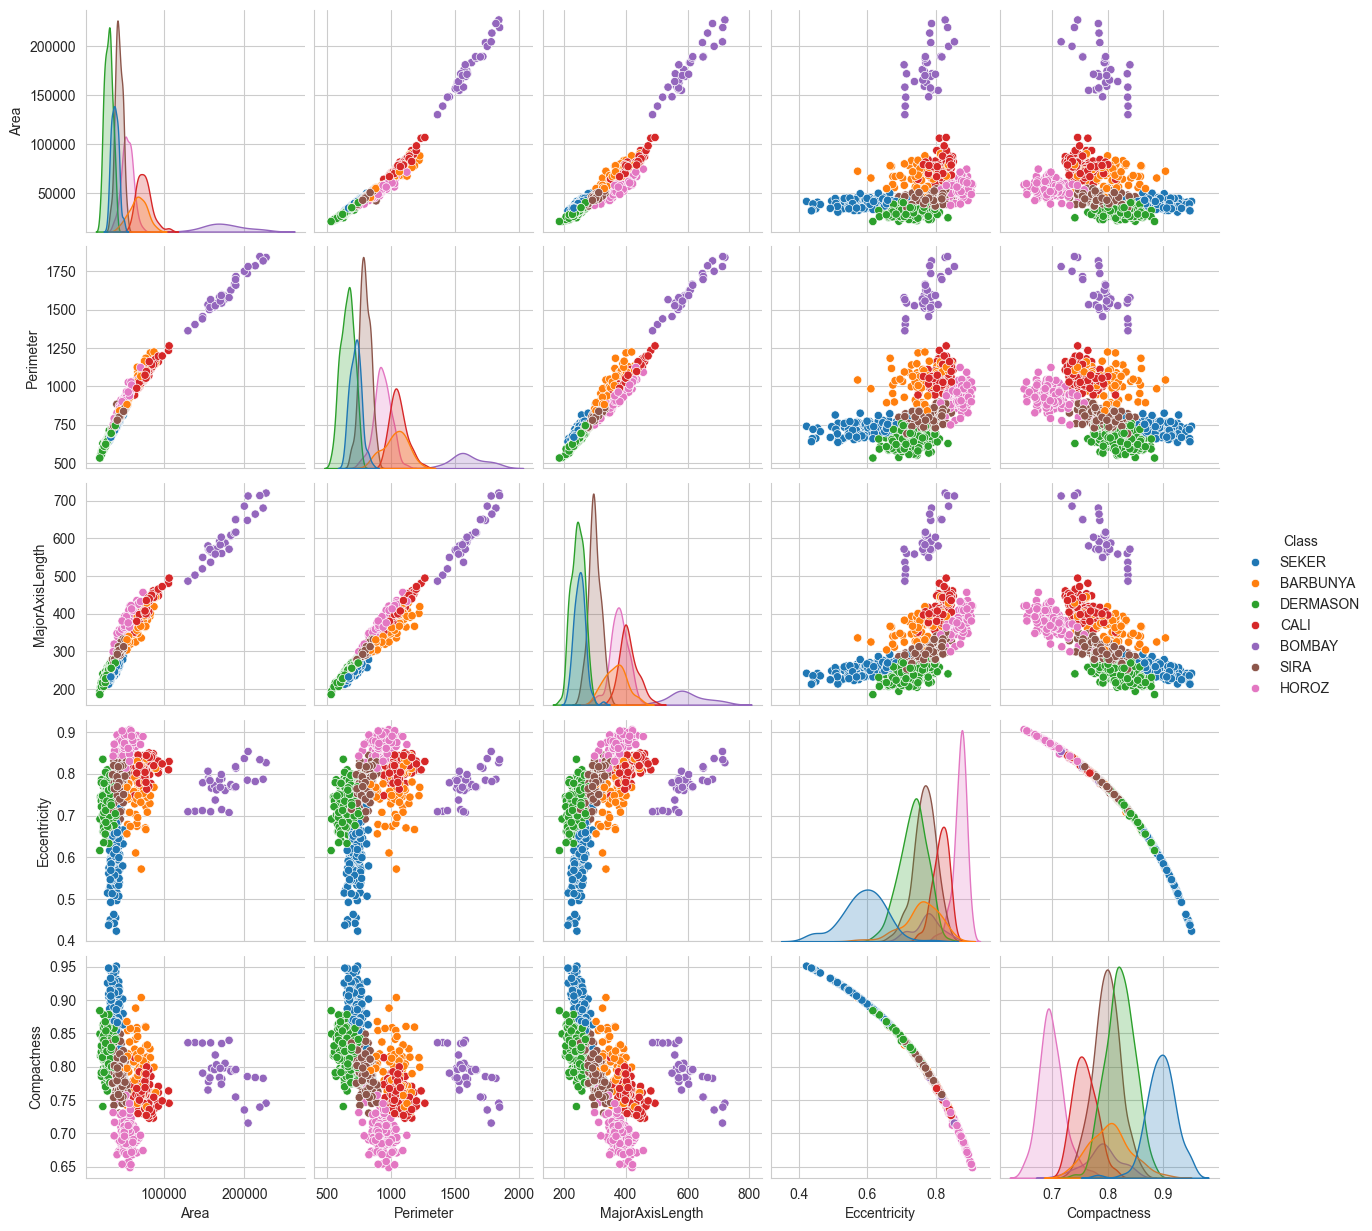

In [9]:
# 2.5 Pairplot on a small sample (full pairplot is heavy with 16 features)
sample = df.sample(n=min(800, len(df)), random_state=RANDOM_STATE)
key_feats = ['Area', 'Perimeter', 'MajorAxisLength', 'Eccentricity', 'Compactness', 'Class']
sns.pairplot(sample[key_feats], hue='Class', diag_kind='kde', palette='tab10')
plt.show()

**EDA findings:**
- The dataset has **7 classes**, with `DERMASON` as the majority (~3.5k samples) and `BOMBAY` as the minority (~520). Imbalance ratio ≈ 6.8.
- Several features (Area, Perimeter, ConvexArea, EquivDiameter) are heavily right-skewed.
- Strong multicollinearity exists among size-related features (Area / ConvexArea / EquivDiameter / Perimeter / MajorAxisLength). Tree-based and SVM models handle this well; we still scale for distance-based models.
- Outliers exist but are mostly the `BOMBAY` class (genuinely larger beans), not data-entry errors — we keep them.

## 3. Missing Values & Outlier Treatment

In [10]:
print('Missing values per column:')
print(df.isnull().sum())
print('\nDuplicate rows:', df.duplicated().sum())

Missing values per column:
Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

Duplicate rows: 68


In [11]:
# Drop duplicates if any
df = df.drop_duplicates().reset_index(drop=True)
print('After de-dup:', df.shape)

# Outlier inspection via IQR — count only, do NOT remove (BOMBAY class would be wiped out)
Q1 = df[feature_cols].quantile(0.25)
Q3 = df[feature_cols].quantile(0.75)
IQR = Q3 - Q1
outlier_mask = ((df[feature_cols] < (Q1 - 1.5 * IQR)) | (df[feature_cols] > (Q3 + 1.5 * IQR)))
print('\nOutlier counts per feature (IQR method):')
print(outlier_mask.sum().sort_values(ascending=False))

After de-dup: (13543, 17)

Outlier counts per feature (IQR method):
Eccentricity       833
Solidity           774
ShapeFactor4       760
MinorAxisLength    567
Area               551
ConvexArea         549
ShapeFactor1       533
EquivDiameter      526
Perimeter          500
AspectRation       485
MajorAxisLength    379
Extent             271
ShapeFactor3       202
Compactness        124
roundness           98
ShapeFactor2         0
dtype: int64


## 4. Feature Engineering & Preprocessing

In [12]:
# Encode the target
le = LabelEncoder()
y = le.fit_transform(df['Class'])
X = df.drop(columns=['Class'])

print('Label mapping:')
for i, cls in enumerate(le.classes_):
    print(f'  {i} -> {cls}')

# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

# Scale features (fit on train only — prevents leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'\nTrain shape: {X_train_scaled.shape}, Test shape: {X_test_scaled.shape}')

Label mapping:
  0 -> BARBUNYA
  1 -> BOMBAY
  2 -> CALI
  3 -> DERMASON
  4 -> HOROZ
  5 -> SEKER
  6 -> SIRA

Train shape: (10834, 16), Test shape: (2709, 16)


## 5. Model Building — Try Multiple Classifiers

In [13]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'Decision Tree':       DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'KNN':                 KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'SVM (RBF)':           SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=RANDOM_STATE),
    'Naive Bayes':         GaussianNB(),
}

results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    train_pred = model.predict(X_train_scaled)
    test_pred  = model.predict(X_test_scaled)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc  = accuracy_score(y_test, test_pred)
    f1        = f1_score(y_test, test_pred, average='weighted')
    cv_score  = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy', n_jobs=-1).mean()
    overfit   = 'Y' if (train_acc - test_acc) > 0.05 else 'N'

    results.append({
        'Model': name,
        'Train Accuracy': round(train_acc, 4),
        'Test Accuracy':  round(test_acc, 4),
        'CV Accuracy':    round(cv_score, 4),
        'F1 Score':       round(f1, 4),
        'Overfitting':    overfit,
    })
    print(f'{name:22s} | Train: {train_acc:.4f} | Test: {test_acc:.4f} | CV: {cv_score:.4f} | F1: {f1:.4f}')

results_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
results_df

Logistic Regression    | Train: 0.9260 | Test: 0.9192 | CV: 0.9246 | F1: 0.9193
Decision Tree          | Train: 1.0000 | Test: 0.8966 | CV: 0.8952 | F1: 0.8964
Random Forest          | Train: 1.0000 | Test: 0.9192 | CV: 0.9235 | F1: 0.9191
KNN                    | Train: 0.9424 | Test: 0.9155 | CV: 0.9211 | F1: 0.9157
SVM (RBF)              | Train: 0.9342 | Test: 0.9210 | CV: 0.9302 | F1: 0.9211
Gradient Boosting      | Train: 0.9646 | Test: 0.9177 | CV: 0.9283 | F1: 0.9177
Naive Bayes            | Train: 0.8972 | Test: 0.8970 | CV: 0.8968 | F1: 0.8972


,Model,Train Accuracy,Test Accuracy,CV Accuracy,F1 Score,Overfitting
0,SVM (RBF),0.9342,0.9210,0.9302,0.9211,N
1,Random Forest,1.0000,0.9192,0.9235,0.9191,Y
2,Logistic Regression,0.9260,0.9192,0.9246,0.9193,N
3,Gradient Boosting,0.9646,0.9177,0.9283,0.9177,N
4,KNN,0.9424,0.9155,0.9211,0.9157,N
5,Naive Bayes,0.8972,0.8970,0.8968,0.8972,N
6,Decision Tree,1.0000,0.8966,0.8952,0.8964,Y


## 6. Handle Class Imbalance with SMOTE

In [14]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print('Before SMOTE:', np.bincount(y_train))
print('After  SMOTE:', np.bincount(y_train_smote))

Before SMOTE: [1057  418 1304 2837 1488 1621 2109]
After  SMOTE: [2837 2837 2837 2837 2837 2837 2837]


In [15]:
# Re-evaluate the top 3 models on SMOTE-balanced data
top_models = results_df.head(3)['Model'].tolist()
smote_results = []

for name in top_models:
    model = models[name]
    model.fit(X_train_smote, y_train_smote)
    test_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, test_pred)
    f1  = f1_score(y_test, test_pred, average='weighted')
    f1_macro = f1_score(y_test, test_pred, average='macro')  # better view of minority-class lift
    smote_results.append({'Model': name, 'Test Accuracy': round(acc,4),
                          'F1 (weighted)': round(f1,4), 'F1 (macro)': round(f1_macro,4)})
    print(f'{name}: acc={acc:.4f}, F1-weighted={f1:.4f}, F1-macro={f1_macro:.4f}')

pd.DataFrame(smote_results)

SVM (RBF): acc=0.9254, F1-weighted=0.9256, F1-macro=0.9360
Random Forest: acc=0.9169, F1-weighted=0.9170, F1-macro=0.9281
Logistic Regression: acc=0.9144, F1-weighted=0.9146, F1-macro=0.9271


,Model,Test Accuracy,F1 (weighted),F1 (macro)
0,SVM (RBF),0.9254,0.9256,0.9360
1,Random Forest,0.9169,0.9170,0.9281
2,Logistic Regression,0.9144,0.9146,0.9271


## 7. Model Evaluation & Overfitting Check

=== Best model: SVM (RBF) ===

              precision    recall  f1-score   support

    BARBUNYA       0.94      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.95      0.93       326
    DERMASON       0.92      0.91      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.93      0.95      0.94       406
        SIRA       0.86      0.88      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



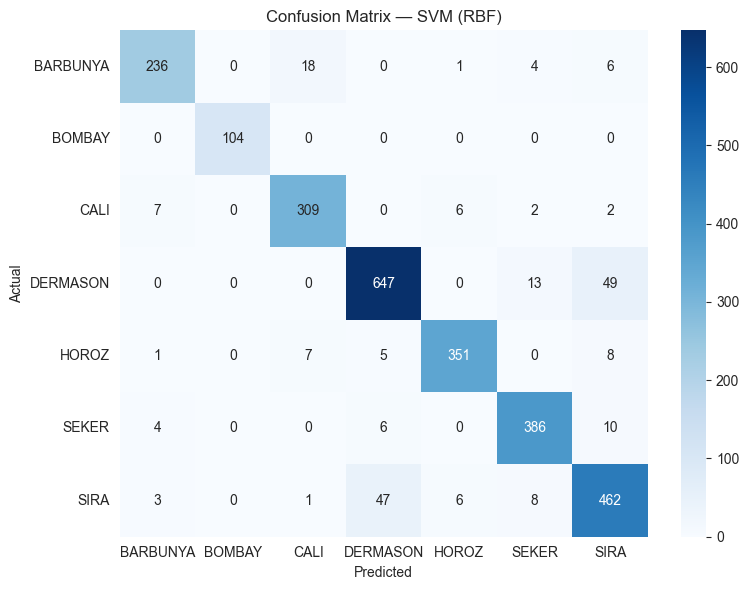

In [16]:
# Pick the best model by test accuracy from the original (non-SMOTE) run
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
# Re-fit on the original (non-SMOTE) scaled data for the deployed model
best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)

print(f'=== Best model: {best_model_name} ===\n')
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix — {best_model_name}')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()

## 8. Hyperparameter Tuning (GridSearchCV)

Tuning the top performer. (Random Forest grid is shown — adjust if your top model was different.)

In [17]:
param_grid_svc = {
    'C':      [0.1, 1, 10, 100],
    'gamma':  ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['rbf'],
}

grid = GridSearchCV(
    SVC(probability=True, random_state=RANDOM_STATE),
    param_grid_svc, cv=3, scoring='accuracy', n_jobs=-1, verbose=1
)
grid.fit(X_train_scaled, y_train)

print('Best params:', grid.best_params_)
print('Best CV score:', round(grid.best_score_, 4))

tuned_model = grid.best_estimator_
tuned_pred  = tuned_model.predict(X_test_scaled)
print('Tuned test accuracy:', round(accuracy_score(y_test, tuned_pred), 4))
print('Tuned F1 (weighted):', round(f1_score(y_test, tuned_pred, average='weighted'), 4))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Best CV score: 0.9322
Tuned test accuracy: 0.9236
Tuned F1 (weighted): 0.9236


## 9. Model Comparison Table

In [22]:
# Append tuned model row
tuned_train_acc = accuracy_score(y_train, tuned_model.predict(X_train_scaled))
tuned_test_acc  = accuracy_score(y_test,  tuned_pred)
tuned_f1        = f1_score(y_test, tuned_pred, average='weighted')
tuned_overfit   = 'Y' if (tuned_train_acc - tuned_test_acc) > 0.05 else 'N'

final_table = pd.concat([
    results_df,
    pd.DataFrame([{
        'Model': 'SVM (RBF) — BEST',
        'Train Accuracy': round(tuned_train_acc, 4),
        'Test Accuracy':  round(tuned_test_acc, 4),
        'CV Accuracy':    round(grid.best_score_, 4),
        'F1 Score':       round(tuned_f1, 4),
        'Overfitting':    tuned_overfit,
    }])
], ignore_index=True)

final_table

,Model,Train Accuracy,Test Accuracy,CV Accuracy,F1 Score,Overfitting
0,SVM (RBF),0.9342,0.9210,0.9302,0.9211,N
1,Random Forest,1.0000,0.9192,0.9235,0.9191,Y
2,Logistic Regression,0.9260,0.9192,0.9246,0.9193,N
3,Gradient Boosting,0.9646,0.9177,0.9283,0.9177,N
4,KNN,0.9424,0.9155,0.9211,0.9157,N
5,Naive Bayes,0.8972,0.8970,0.8968,0.8972,N
6,Decision Tree,1.0000,0.8966,0.8952,0.8964,Y
7,SVM (RBF) — BEST,0.9397,0.9236,0.9322,0.9236,N


## 10. Save Artifacts for Streamlit App

We persist three files that `streamlit_app.py` will load at startup:
- `bean_model.pkl` — the tuned classifier
- `scaler.pkl` — the fitted `StandardScaler`
- `label_encoder.pkl` — the fitted `LabelEncoder`

We also persist `feature_columns.pkl` so the app knows the exact column order to feed the model.

In [23]:
joblib.dump(tuned_model, 'bean_model.pkl')
joblib.dump(scaler,      'scaler.pkl')
joblib.dump(le,          'label_encoder.pkl')
joblib.dump(list(X.columns), 'feature_columns.pkl')

# Also save min/max of each feature to drive sensible Streamlit slider ranges
feature_ranges = {
    col: {'min': float(df[col].min()),
          'max': float(df[col].max()),
          'mean': float(df[col].mean())}
    for col in X.columns
}
joblib.dump(feature_ranges, 'feature_ranges.pkl')

print('Saved: bean_model.pkl, scaler.pkl, label_encoder.pkl, feature_columns.pkl, feature_ranges.pkl')
print('\nNow run:  streamlit run streamlit_app.py')

Saved: bean_model.pkl, scaler.pkl, label_encoder.pkl, feature_columns.pkl, feature_ranges.pkl

Now run:  streamlit run streamlit_app.py


## 11. Quick sanity check — load artifacts and predict one sample

In [24]:
loaded_model   = joblib.load('bean_model.pkl')
loaded_scaler  = joblib.load('scaler.pkl')
loaded_le      = joblib.load('label_encoder.pkl')
loaded_columns = joblib.load('feature_columns.pkl')

sample_row = X_test.iloc[[0]]
true_label = loaded_le.inverse_transform([y_test[0]])[0]

scaled = loaded_scaler.transform(sample_row[loaded_columns])
pred   = loaded_model.predict(scaled)
pred_label = loaded_le.inverse_transform(pred)[0]

print(f'True : {true_label}')
print(f'Pred : {pred_label}')

True : SEKER
Pred : SEKER
